In [1]:
import math
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
random.seed(42)

### figuring out derivatives

In [3]:
def f(x):
    return 3*x**2 - 4*x + 5

In [4]:
f(3.0)

20.0

In [5]:
xs = np.arange(-5 ,5, 0.25) # range of x values from -5 to 5 with a gap of 0.25
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [6]:
ys = f(xs) # generating y for each generated x value
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

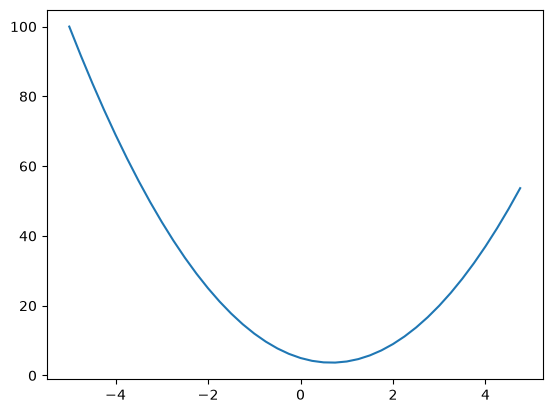

In [7]:
plt.plot(xs, ys) # plot of the x and y values generated from the f(x) func

A TL;DR understanding of a derivative, its used to figure out how the function responds to a variable $x$ being increased slightly. Does the function's output slightly go up or down? Also called slope.

It tells you how sensitive the function's output is to the variable $x$ change, and how it responds to the change.

$L = \lim_{h \to 0} \frac{f(x+h)-f(x)}{h}$

here $h$ is the minute change we are making to x to see its effects on the function output.

In [8]:
h = 0.0001
x = 3.0
print(f"f(x) = {f(x)}")
print(f"f(x+h) =  {f(x+h)}")

f(x) = 20.0
f(x+h) =  20.001400030000006


As we could already see from the above parabola shape, after ~0.5 the y values starts to increase. So any nudging of x in the positive direction was going to increase the y value. Lets point it out on the plot:

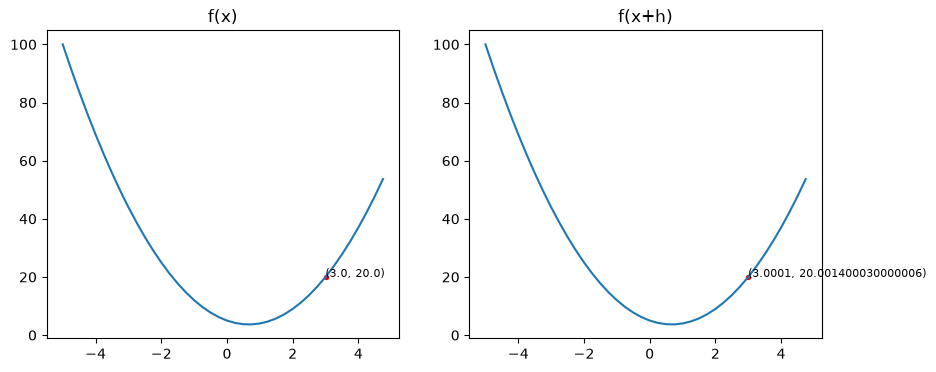

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# left plot f(x)
y = f(x)
ax[0].plot(xs, ys)
ax[0].scatter(x, y, color='red', s=8)
ax[0].text(x, y, f'({x}, {y})', fontsize=8)
ax[0].set_title("f(x)")

# light plot f(x+h)
y = f(x + h)
ax[1].plot(xs, ys)
ax[1].scatter(x + h, y, color='red', s=8)
ax[1].text(x + h, y, f'({x+h}, {y})', fontsize=8)
ax[1].set_title("f(x+h)")

plt.show()

So, a nudging of $h = 0.01$ to $x$ yields a slope of:

In [10]:
(f(x+h) - f(x))/h

14.000300000063248

Now, the lowest dip for $y$ lies roughly at $2/3$, so if we set $x=2/3$, what happens?

In [11]:
x = 2/3
(f(x+h) - f(x))/h

0.0002999999981767587

The slope becomes flat, as seems evident from the plot

In [12]:
# now lets compute derivative of a value based on multiple values:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [13]:
# Lets calculate effect of 'a' being nudged on the value of 'd'
h = 0.0001

a = 2.0
b = -3.0
c = 10.0
d1 = a*b + c # og value

a += h # nudging positively slightly

d2 = a*b + c # after nudging

print('d1', d1)
print('d2', d2)

print('Slope:', (d2 - d1)/h)

d1 4.0
d2 3.999699999999999
Slope: -3.000000000010772


Neural nets are huge expressions, so lets make some classes to represent data more appropriately

In [14]:
class Value:
    # _children is meant to keep track of the values that underwent an operation to generate this value.
    # _op keeps track of the operation that was done by parent Values to generate this value.
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self): # displays our own data value
        return f"Value(data={self.data})"
    
    def __add__(self, other): # here other is another Value object
        other = other if isinstance(other, Value) else Value(other) # if the passed entity is a Value object then fine, if not then simply wrap it in Value
        out = Value(self.data + other.data, (self, other), '+') # (self, other) = parent Values operating to generate child Value, '+' is the operation done to generate
        def _backward():
            # As mentioned before, '+' operator simply passes the gradient backwards without change.

            # We're writing += instead of + because if a node is being accessed multiple times by different nodes, we want the gradient to not be overridden, but rather accumulated. Hence we add
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) # if the passed entity is a Value object then fine, if not then simply wrap it in Value
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            # As mentioned before, in multiplicative gradient derivation, you take the other node's data, and multiply with the resultant node's grad
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "Only int and float support for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * (self.data**(other-1)) * out.grad
        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * other**-1
    
    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def exp(self):
        x = self.data 
        out = Value(math.exp(x), (self, ), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)  - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh') # children = (self, ) since this is a single object

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out
    
    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0

        for node in reversed(topo):
            node._backward()
        


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
print(f'Addition: {a + b}')
print(f'Subtraction: {a - b}')
print(f'Multiplication: {a * b}')
print(f'Division: {a / b}')

print(f'Division: {(a / b).data:.1f}') # Fetching data directly and limiting float length

print(f'Can also add a normal number', a + 10)
print(f'Can also multiply a normal number', a * 10)

Addition: Value(data=-1.0)
Subtraction: Value(data=5.0)
Multiplication: Value(data=-6.0)
Division: Value(data=-0.6666666666666666)
Division: -0.7
Can also add a normal number Value(data=12.0)
Can also multiply a normal number Value(data=20.0)


In [15]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
# under the hood this looks like:
# (a.__mul__(b)).__add__(c)


In [16]:
d._prev # here -6 is due to a*b , and 10 from c. So a computation graph is being kept
d._op # here '+' because a*b and c were added to get d

'+'

In [17]:
import os
os.environ["PATH"] += r";C:\Program Files (x86)\Graphviz\bin"

In [18]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [19]:
L.grad = 1.0

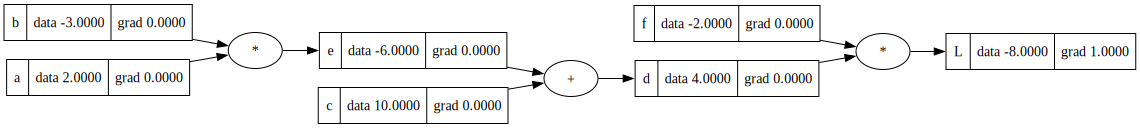

In [20]:
draw_dot(L)

Reading for generating this compute graph is partially visual, but this shows all the calculation done to end up with the value $L$. What we want to do is to backpropagate backwards from L to all the previous values. We wanna know the derivative of every Value with respect to L, such as the derivative of $L$ with respect to $L$ (which would be 1), $d, f, e, c, a, b$

L = d * f

$\frac{dL}{dd}$ (derivative of L with respect to d) = $f$

$\frac{(f(x+h) - f(x))}{h}$

here x = d

$\frac{dL}{dd} = \frac{(d+h)*f - d*f}{h}$

$\frac{dL}{dd} = \frac{(\cancel{d*f} + h*f - \cancel{d*f})}{h}$

$\frac{dL}{dd} = \frac{\cancel{h}*f}{\cancel{h}}$

$\frac{dL}{dd} = f$

Symmetrically, $\frac{dL}{dd} = f = -2$, and $\frac{dL}{df} = d = 4$

In [21]:
# Manually setting gradients according to the above observation:
f.grad = 4.0
d.grad = -2.0

Now to derive $\frac{dL}{dc}$ (apparently the most important derivation)

Before doing that, lets first figure out $\frac{dd}{dc}$

d = c + e

$\frac{(f(x+h) - f(x))}{h}$

x = c

$\frac{dd}{dc} = \frac{((c+h) + e) - (c + e)}{h}$

$\frac{dd}{dc} = \frac{c + h + e - c - e}{h}$

$\frac{dd}{dc} = \frac{\cancel{c} + h \cancel{+ e} \cancel{- c} \cancel{- e}}{h}$

$\frac{dd}{dc} = \frac{\cancel{h}}{\cancel{h}} = 1.0$

Symmetrically, $\frac{dd}{de} = 1.0$

Chain Rule time. 

As seen in the above diagram of the nodes, $L$ is directly connected to $d$ and $f$, but indirectly connected to $c$ and $e$. Therefore $\frac{dL}{dd}$ & $\frac{dL}{df}$ can be derived very simply. But when trying to derive indirectly connected nodes such as $\frac{dL}{dc}$, we need the Chain Rule which states:

$\Large \frac{dL}{dc} = \frac{dL}{dy} * \frac{dy}{dc}$

Intuitively it can be understood as a product of two rates of changes. Say a car is moving $2$ times the speed of a cycle, and a cycle is moving at $5$ times the speed of a person, then a car is moving at $2*5 = 10$ times the speed of a person

So, now that we have the formula, what we want is: $\frac{dL}{dc}$. Chain Rule says: $\Large \frac{dL}{dc} = \frac{dL}{dd} * \frac{dd}{dc}$. We already have $\frac{dL}{dd} = -2.0$, and $\frac{dd}{dc} = 1.0$

So $\large \frac{dL}{dc} = \frac{dL}{dd} * \frac{dd}{dc} = -2.0 * 1.0$ => $\mathbf{\Large \frac{dL}{dc}} = -2.0$.

Symmetrically, $\large \frac{dL}{de} = \frac{dL}{dd} * \frac{dd}{de} = -2.0 * 1.0$ => $\mathbf{\Large \frac{dL}{de}} = -2.0$

To squish all this into an intuition, we can think of it as the $+$ node routing the gradient through to the previous node without any changes.

In [22]:
# Based on the chain rule above, lets hardcode the values
c.grad = -2.0
e.grad = -2.0

Lets quickly compute the last nodes $a$ and $b$

WANT: $\frac{dL}{da}$ and $\frac{dL}{db}$

Chain Rule: $\Large \mathbf{\frac{dL}{da}} = \frac{dL}{de} * \frac{de}{da}$ & $\Large \mathbf{\frac{dL}{db}} = \frac{dL}{de} * \frac{de}{db}$

$\Large \mathbf{\frac{de}{da}} = \frac{((a+h) * b) - (a * b)}{h}$

$\frac{de}{da} = \frac{(a * b + h * b) - (a * b)}{h}$

$\frac{de}{da} = \frac{\cancel{a * b} + h * b - \cancel{a * b}}{h}$

$\frac{de}{da} = \frac{\cancel{h} * b}{\cancel{h}}$

$\frac{de}{da} = b = -3$

$\Large \mathbf{\frac{de}{db}} = \frac{(a * (b + h)) - (a * b)}{h}$

$\frac{de}{db} = \frac{(a * b + a * h) - (a * b)}{h}$

$\frac{de}{db} = \frac{(\cancel{a * b} + a * h - \cancel{a * b})}{h}$

$\frac{de}{db} = \frac{a * \cancel{h}}{\cancel{h}}$

$\frac{de}{db} = a = 2$

Now that we have all the pieces:

$\large \mathbf{\frac{dL}{da}} = \frac{dL}{de} * \frac{de}{da} = -2 * -3 = \mathbf{6}$

$\large \mathbf{\frac{dL}{db}} = \frac{dL}{de} * \frac{de}{db} = -2 * 2 = \mathbf{-4}$

In [23]:
# based on the above calculation:
a.grad = -2.0 * -3.0
b.grad = -2.0 * 2.0

# We can decompose this into a rough general formula for calculating gradients: Value of other node's data * gradient of resultant node.

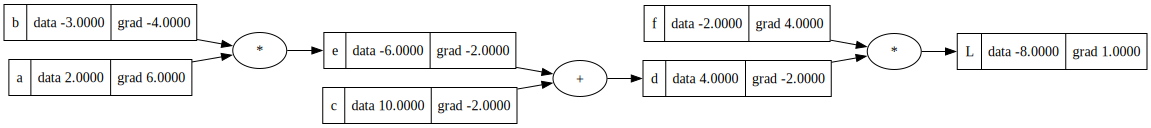

In [24]:
draw_dot(L)

In [25]:
# Lets do a forward pass

a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = f * d

print(L.data) # We expect a more positive value since we've moved all leaf nodes in the direction of gradient

-7.286496


In [26]:
def grad_test():
    
    h = 0.0001
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')

    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1) / h)

grad_test()

0.0


#### Neuron Time

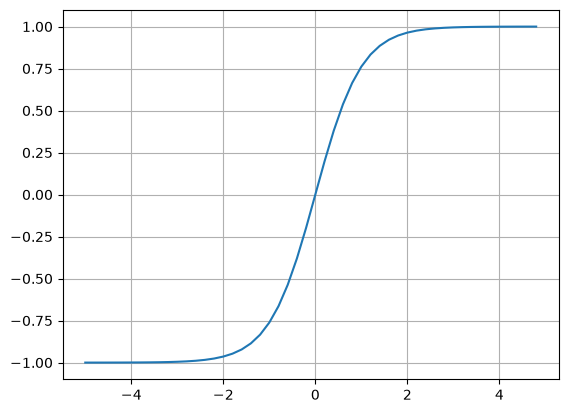

In [27]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid();

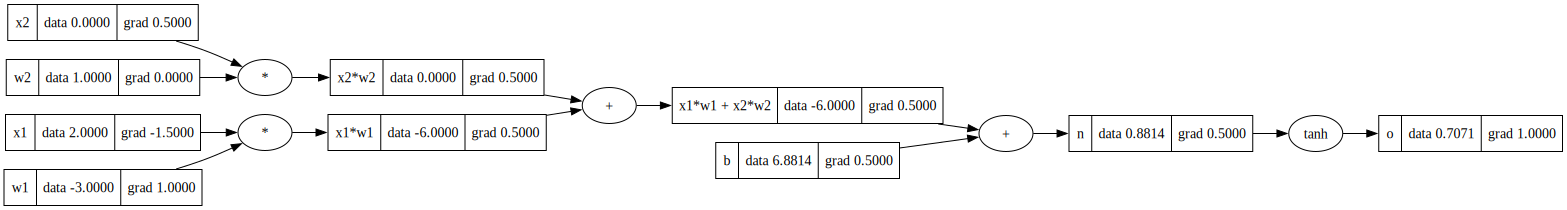

In [28]:
# Lets make a toy 2d neuron

# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias b
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o' # Job of tanh is to squash values greater than 1 down smoothly.
o.backward()
draw_dot(o)

Instead of manual backprop, now we simply call _backward function one by one after initializing last node grad as 1.0

In [29]:
# o.grad = 1.0 # since dO/dO is 1.0
# o._backward()
# n._backward()
# x1w1x2w2._backward()
# x1w1._backward()
# x2w2._backward()

Better yet we can use a topological sort to sort all the nodes in our graph in a linear format, and then call backward (Placed in Value class)

In [30]:
# o.grad = 1.0

# topo = []
# visited = set()
# def build_topo(v):
#     if v not in visited:
#         visited.add(v)
#         for child in v._prev:
#             build_topo(child)
#         topo.append(v)
# build_topo(o)
# topo

# for node in reversed(topo):
#     node._backward()

Manual backprop, defunct after the _backward function implementation

In [31]:
# # to figure out dO/dn, we need a derivation of tanh, which is = 1 - tanh(n)**2, and tanh(n) is 'o' so
# 1 - o.data**2
# # So approximately:
# n.grad = 0.5
# # As we remember, the '+' operator simply passes the gradient backwards without modification, so:
# x1w1x2w2.grad = 0.5
# b.grad = 0.5
# # Again, plus sign, so gradients get passed backwards without change.
# x1w1.grad = 0.5
# x2w2.grad = 0.5
# # Since now we're dealing with multiplicative nodes, the general formula for figuring out the gradient is = other node's data * resultant node's gradient so
# x1.grad = w1.data * x1w1.grad
# w1.grad = x1.data * x1w1.grad
# # Similarly, do the same multiplicative gradient formula for x2 and w2
# x2.grad = w2.data * x2w2.grad
# w2.grad = x2.data * x2w2.grad

Bug Test

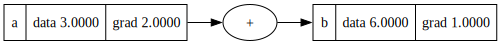

In [32]:
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

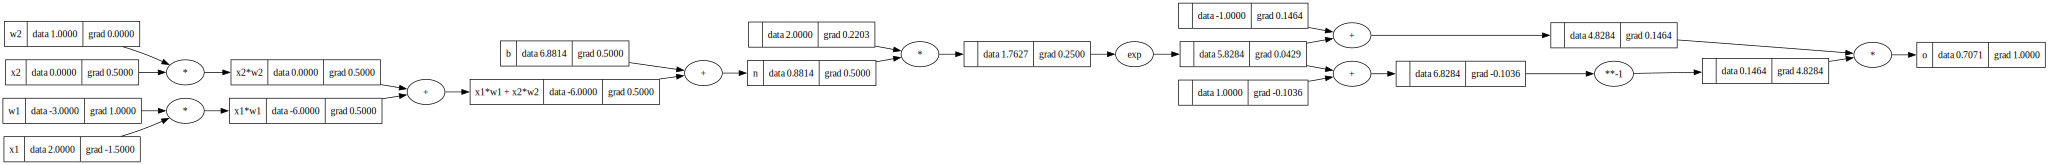

In [33]:
# Decomposing Tanh

# Lets make a toy 2d neuron

# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias b
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp()
o = (e - 1)/(e + 1); o.label = 'o'
o.backward()
draw_dot(o)

The results are the same when done with PyTorch. Thus validating our code

In [34]:
# import torch

# x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
# x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
# w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
# w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
# b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
# n = x1*w1 + x2*w2 + b
# o = torch.tanh(n)

# print(o.data.item())
# o.backward()

# print('---')
# print('x2', x2.grad.item())
# print('w2', w2.grad.item())
# print('x1', x1.grad.item())
# print('w1', w1.grad.item())

Neural Network time. We've figured out how backpropagation works, and have written a successfully written backpropagation code to run a backward pass. Now to write neural network code

In [35]:
class Neuron:
    def __init__(self, nin): # nin is number of inputs a neuron receives
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x): # called when a notation like n(x) is used.
        # w * x + b | w * x is dot product

        # zip means to take two iterators (w and x) and join them into a new iterator like (w, x).
        # We're taking each paired weight and input and multiplaying them, then summing all the multiplications.
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh() # non-linearity
        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout): # nin = dimensionality of neuron in layer, nout = number of neurons in layer
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs # if layer only outputs one value, then output the 0th index otherwise output full list
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters() # parameters of the neuron in the layer
        #     params.extend(ps) # adding all the parameters of all the neurons in the layer
        #     return params

class MLP:
    def __init__(self, nin, nouts): # nin = number of inputs in the MLP, nouts = list of number of neurons in each layer of the MLP
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
        
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

# x = [2.0, 3.0] # input
# n = Neuron(2) # 2D neuron
# n(x)
# n = Layer(2, 3) # Layer of 3 neurons of 2D dimensionality
# n(x)

In [36]:
x = [2.0, 3.0] # input
n = MLP(3, [4, 4, 1]) # look below for the image we're replicating. 3 is input shape, 4 and 4 is the intermediate layer's no. of neurons, and 1 is the last layer's no. of neurons.
n(x)

Value(data=0.5407088488185408)

In [37]:
len(n.parameters())

41

Image we're trying to replicate is:

In [38]:
from IPython.display import Image
url = "https://cs231n.github.io/assets/nn1/neural_net2.jpeg"
Image(url=url, width=400)

In [39]:
# draw_dot(n(x))

Now we have the Neuron, Layer, and an MLP defined. Let's make a tiny dataset and try and make our MLP learn.

In [40]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [41]:
# Lets see what the neural net thinks the output should be without training.
ypred = [n(x) for x in xs]
ypred

[Value(data=0.6994093620224068),
 Value(data=0.5026295816615511),
 Value(data=0.6931545900944501),
 Value(data=0.8755224728708613)]

To figure out how badly the neural net sucks, we need a single number that dictates how bad or good the NN is doing. We call this number loss. In our case, lets calculate the loss value using something called **Mean Squared Error**

In [42]:
# Get the ground truth values ys, subtract the predicted values, and square the subtraction, then sum all the values
loss = sum([(y_output - y_ground_truth)**2 for y_ground_truth, y_output in zip(ys, ypred)])
loss

Value(data=5.230517512042234)

Moment of truth. We have the MLP, we have the loss, now its time to backpropagate:

In [43]:
loss.backward()

In [44]:
print(f"Neuron Value: {n.layers[0].neurons[0].w[0].data}, \nNeuron Gradient: {n.layers[0].neurons[0].w[0].grad}")

Neuron Value: 0.2788535969157675, 
Neuron Gradient: -1.3722609374247599


Now we have the parameters of every neuron in this network (41), lets make a small change in each neuron's data based on the gradient:

In the below cell, we write $\large{-}$ 0.01 instead of simply 0.01. Why? It is because the gradient points in the direction that is meant to **increase** the value of the loss. But we don't want that. We want the opposite, therefore we move in the opposite direction.

In [45]:
for p in n.parameters():
    p.data += -0.01 * p.grad

In [46]:
print(f"Neuron Value: {n.layers[0].neurons[0].w[0].data}, \nNeuron Gradient: {n.layers[0].neurons[0].w[0].grad}")

Neuron Value: 0.2925762062900151, 
Neuron Gradient: -1.3722609374247599


Lets recalculate the loss once more. To see if our gradient descent has lowered the loss value:

In [47]:
ypred = [n(x) for x in xs]
loss = sum([(y_output - y_ground_truth)**2 for y_ground_truth, y_output in zip(ys, ypred)])
loss

Value(data=4.561050613053606)

Lower than before, Yippie!

So lets do a couple of steps of forward, and backward pass and get the loss very low:

In [58]:
for k in range(20):
    
    # Forward Pass
    ypred = [n(x) for x in xs]
    loss = sum([(y_output - y_ground_truth)**2 for y_ground_truth, y_output in zip(ys, ypred)]) # Compute Loss

    # Flush the gradients (Zero Grad)
    for p in n.parameters():
        p.grad = 0.0
    
    # Backward Pass
    loss.backward()

    # Update
    for p in n.parameters():
        p.data += -0.08 * p.grad
    
    print(f"Step: {k+1} | Loss: {loss.data}")

Step: 1 | Loss: 0.0032603214085898716
Step: 2 | Loss: 0.003239684755280926
Step: 3 | Loss: 0.0032192954159298627
Step: 4 | Loss: 0.003199149065446982
Step: 5 | Loss: 0.0031792414777530704
Step: 6 | Loss: 0.0031595685229858206
Step: 7 | Loss: 0.003140126164799746
Step: 8 | Loss: 0.003120910457755916
Step: 9 | Loss: 0.0031019175447981294
Step: 10 | Loss: 0.003083143654812251
Step: 11 | Loss: 0.0030645851002654564
Step: 12 | Loss: 0.00304623827492241
Step: 13 | Loss: 0.003028099651635623
Step: 14 | Loss: 0.0030101657802067095
Step: 15 | Loss: 0.002992433285316793
Step: 16 | Loss: 0.0029748988645224217
Step: 17 | Loss: 0.002957559286315547
Step: 18 | Loss: 0.002940411388244496
Step: 19 | Loss: 0.002923452075094252
Step: 20 | Loss: 0.002906678317123441


In [59]:
for pred, gt in zip(ypred, ys):
    print(f"{gt:>5.1f} | {pred.data:>8.4f}")

  1.0 |   0.9745
 -1.0 |  -0.9840
 -1.0 |  -0.9635
  1.0 |   0.9742
